In [1]:
import os.path as op

import matplotlib.pyplot as plt
import nibabel as nib
import plotly
import pandas as pd

from AFQ.api.group import GroupAFQ
import AFQ.data.fetch as afd
import AFQ.viz.altair as ava
import AFQ.definitions.image as afm


some basic useful functions for later
| Function                     | When you'll need it                                                        |
| ---------------------------- | -------------------------------------------------------------------------- |
| `fetch_hcp_atlas_80_bundles` | More complete bundle set for Dice comparison                               |
| `fetch_slf_templates`        | Superior longitudinal fasciculus (SLF) templates; may be missing otherwise |
| `fetch_ar_templates`         | Acoustic radiation tract templates                                         |
| `fetch_biobank_templates`    | UK Biobank template space; skip for now                                    |
| `fetch_pediatric_templates`  | Pediatric templates; skip because HCP YA contains adult subjects           |


In [2]:
bids_path = afd.fetch_hbn_preproc(
    ["NDARAA948VFH"],
    clear_previous_afq="all")[1]


In [3]:
tracking_params = dict(n_seeds=1e5,
                       random_seeds=True,
                       rng_seed=2025,
                       trx=True)


In [4]:
pve = afm.PVEImages(
    afm.ImageFile(
        suffix="probseg", filters={"scope": "qsiprep", "label": "CSF"}),
    afm.ImageFile(
        suffix="probseg", filters={"scope": "qsiprep", "label": "GM"}),
    afm.ImageFile(
        suffix="probseg", filters={"scope": "qsiprep", "label": "WM"}))


In [5]:
brain_mask_definition = afm.ImageFile(
    suffix="mask", filters={"desc": "brain", "scope": "qsiprep"})


### Initialize a GroupAFQ object:
Creates a GroupAFQ object, that encapsulates tractometry. This object can be used to manage the entire :doc:/explanations/index, including:

- Tractography

- Registration

- Segmentation

- Cleaning

- Profiling

- Visualization

This will also create an output folder for the corresponding AFQ derivatives in the AFQ data directory: AFQ_data/HBN/derivatives/afq/

- To initialize this object we will pass in the path location to our BIDS compliant data, the name of the preprocessing pipeline we want to use, the name of the t1 preprocessing pipeline we want to use (in this case, its the same, qsiprep [3]), the participant labels we want to process (in this case, just a single subject), the PVE images we defined above, and the tracking parameters we defined above.



In [7]:
myafq = GroupAFQ(
    bids_path=op.join(afd.afq_home, 'HBN'),
    dwi_preproc_pipeline='qsiprep',
    t1_preproc_pipeline='qsiprep',
    participant_labels=['NDARAA948VFH'],
    pve=pve,
    brain_mask_definition=brain_mask_definition,
    tracking_params=tracking_params)


INFO:AFQ:Using the following files for subject NDARAA948VFH and session HBNsiteRU:
INFO:AFQ:  DWI: /Users/applejuiceleigh/AFQ_data/HBN/derivatives/qsiprep/sub-NDARAA948VFH/ses-HBNsiteRU/dwi/sub-NDARAA948VFH_ses-HBNsiteRU_acq-64dir_space-T1w_desc-preproc_dwi.nii.gz
INFO:AFQ:  BVAL: /Users/applejuiceleigh/AFQ_data/HBN/derivatives/qsiprep/sub-NDARAA948VFH/ses-HBNsiteRU/dwi/sub-NDARAA948VFH_ses-HBNsiteRU_acq-64dir_space-T1w_desc-preproc_dwi.bval
INFO:AFQ:  BVEC: /Users/applejuiceleigh/AFQ_data/HBN/derivatives/qsiprep/sub-NDARAA948VFH/ses-HBNsiteRU/dwi/sub-NDARAA948VFH_ses-HBNsiteRU_acq-64dir_space-T1w_desc-preproc_dwi.bvec
INFO:AFQ:  T1: /Users/applejuiceleigh/AFQ_data/HBN/derivatives/qsiprep/sub-NDARAA948VFH/anat/sub-NDARAA948VFH_desc-preproc_T1w.nii.gz


In [8]:
myafq = GroupAFQ(
    bids_path=op.join(afd.afq_home, 'HBN'),
    dwi_preproc_pipeline='qsiprep',
    t1_preproc_pipeline='qsiprep',
    participant_labels=['NDARAA948VFH'],
    pve=pve,
    brain_mask_definition=brain_mask_definition,
    tracking_params=tracking_params)


INFO:AFQ:Using the following files for subject NDARAA948VFH and session HBNsiteRU:
INFO:AFQ:  DWI: /Users/applejuiceleigh/AFQ_data/HBN/derivatives/qsiprep/sub-NDARAA948VFH/ses-HBNsiteRU/dwi/sub-NDARAA948VFH_ses-HBNsiteRU_acq-64dir_space-T1w_desc-preproc_dwi.nii.gz
INFO:AFQ:  BVAL: /Users/applejuiceleigh/AFQ_data/HBN/derivatives/qsiprep/sub-NDARAA948VFH/ses-HBNsiteRU/dwi/sub-NDARAA948VFH_ses-HBNsiteRU_acq-64dir_space-T1w_desc-preproc_dwi.bval
INFO:AFQ:  BVEC: /Users/applejuiceleigh/AFQ_data/HBN/derivatives/qsiprep/sub-NDARAA948VFH/ses-HBNsiteRU/dwi/sub-NDARAA948VFH_ses-HBNsiteRU_acq-64dir_space-T1w_desc-preproc_dwi.bvec
INFO:AFQ:  T1: /Users/applejuiceleigh/AFQ_data/HBN/derivatives/qsiprep/sub-NDARAA948VFH/anat/sub-NDARAA948VFH_desc-preproc_T1w.nii.gz


### Calculating DTI FA (Diffusion Tensor Imaging Fractional Anisotropy)
The GroupAFQ object has a method called export, which allows the user to calculate various derived quantities from the data.

For example, FA can be computed using the DTI model, by explicitly calling myafq.export("dti_fa"). This triggers the computation of DTI parameters for all subjects in the dataset, and stores the results in the AFQ derivatives directory. In addition, it calculates the FA from these parameters and stores it in a different file in the same directory.



In [9]:
FA_fname = myafq.export("dti_fa", collapse=False)["NDARAA948VFH"]["HBNsiteRU"]

# We will then use `nibabel` to load the deriviative file and retrieve the
# data array.

FA_img = nib.load(FA_fname)
FA = FA_img.get_fdata()


INFO:AFQ:Calculating _b0ref.nii.gz...
INFO:AFQ:_b0ref.nii.gz completed. Saving to /Users/applejuiceleigh/AFQ_data/HBN/derivatives/afq/sub-NDARAA948VFH/ses-HBNsiteRU/dwi/sub-NDARAA948VFH_ses-HBNsiteRU_acq-64dir_b0ref.nii.gz
INFO:AFQ:Calculating _desc-brain_mask.nii.gz...
INFO:AFQ:Calculating _desc-T1w_mask.nii.gz...
INFO:AFQ:_desc-T1w_mask.nii.gz completed. Saving to /Users/applejuiceleigh/AFQ_data/HBN/derivatives/afq/sub-NDARAA948VFH/ses-HBNsiteRU/dwi/sub-NDARAA948VFH_ses-HBNsiteRU_acq-64dir_desc-T1w_mask.nii.gz
INFO:AFQ:_desc-brain_mask.nii.gz completed. Saving to /Users/applejuiceleigh/AFQ_data/HBN/derivatives/afq/sub-NDARAA948VFH/ses-HBNsiteRU/dwi/sub-NDARAA948VFH_ses-HBNsiteRU_acq-64dir_desc-brain_mask.nii.gz
INFO:AFQ:Calculating _model-tensor_param-diffusivity_dwimap.nii.gz, _model-tensor_param-s0_dwimap.nii.gz...
INFO:AFQ:_model-tensor_param-diffusivity_dwimap.nii.gz completed. Saving to /Users/applejuiceleigh/AFQ_data/HBN/derivatives/afq/sub-NDARAA948VFH/ses-HBNsiteRU/dwi/models

(np.float64(-0.5), np.float64(128.5), np.float64(107.5), np.float64(-0.5))

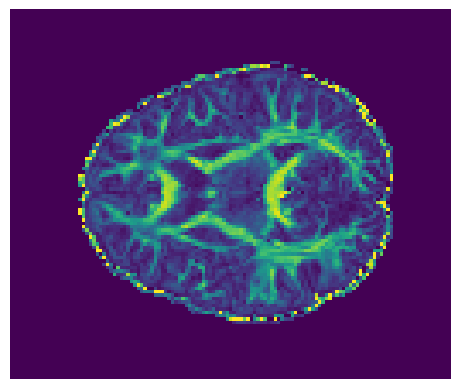

In [10]:
fig, ax = plt.subplots(1)
ax.matshow(FA[:, :, FA.shape[-1] // 2], cmap='viridis')
ax.axis("off")


### Recognizing the bundles and calculating tract profiles:
Typically, users of pyAFQ are interested in calculating not only an overall map of the FA, but also the major white matter pathways (or bundles) and tract profiles of tissue properties along their length. To trigger the pyAFQ pipeline that calculates the profiles, users can call the export('profiles') method:



In [18]:
import AFQ.data.fetch as afd
import time

fetchers = [
    afd.fetch_or_templates,
    afd.fetch_templates,
    afd.fetch_callosum_templates,
    afd.fetch_slf_templates,
    afd.fetch_ar_templates,
    afd.fetch_hcp_atlas_16_bundles,
]

for fn in fetchers:
    print(f"Running {fn.__name__}...")
    fn()
    print(f"  ✓ done — waiting 15s before next fetch...")
    time.sleep(15)

Running fetch_or_templates...


  0%|          | 0/2 MB [00:00]

  0%|          | 0/1 MB [00:00]

  0%|          | 0/2 MB [00:00]

  0%|          | 0/1 MB [00:00]

...

  0%|          | 0/16 MB [00:00]

  0%|          | 0/16 MB [00:00]

  0%|          | 0/1 MB [00:00]

  0%|          | 0/1 MB [00:00]

  ✓ done — waiting 15s before next fetch...
Running fetch_hcp_atlas_16_bundles...
  ✓ done — waiting 15s before next fetch...


In [19]:
## earlier the gz files were saved as html files,
## there was an error in the PyAFQ tutorial due to old versions of the templates
myafq.export('profiles')


INFO:AFQ:Calculating _desc-bundles_tractography...
ERROR:AFQ:Error in task: segment


ImageFileError: File /Users/applejuiceleigh/AFQ_data/or_templates/right_V1_MNI.nii.gz is not a gzip file